# Image Prediction Trajectories: Integrated Analysis

This notebook analyzes the prefix predictions of the final ordered image LSTM.

Each reenactment contributes two 30-frame image sequences: one **Central** and one **Side** view. At prefix length `t`, the model prediction is based on the first `t` frames of the corresponding view sequence.

The analysis mirrors the FEA prediction-trajectory analysis and adds view-specific checks where appropriate. Prefixes are analyzed descriptively; they are not separately trained early-classification models.

## 1. Setup and input validation

In [1]:
from pathlib import Path
import base64
import hashlib
import html
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter


INPUT_PATH = Path('image_prediction_trajectories.csv')

OUTPUT_DIR = Path('outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = [
    'Anger',
    'Disgust',
    'Fear',
    'Happiness',
    'Neutral',
    'Sadness',
    'Surprise',
]

PROB_COLS = [
    f'probability_{name.lower()}'
    for name in CLASSES
]

SEQUENCE_LENGTH = 30
N_SEQUENCES = 756
N_REENACTMENTS = 378
N_CLASSES = 7


def finish_figure(fig, name, show=True):
    png_path = FIG_DIR / f'{name}.png'
    pdf_path = FIG_DIR / f'{name}.pdf'
    fig.savefig(png_path, dpi=200, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    if show:
        plt.show()

    plt.close(fig)


def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


In [2]:
df = pd.read_csv(INPUT_PATH)

required = {
    'sample_id',
    'sequence_id',
    'reenactment_id',
    'sequence_timestamp',
    'set_id',
    'participant_id',
    'level_id',
    'emoji_id',
    'camera_index',
    'perspective',
    'image_sequence_path',
    'timestep',
    'frame_timestamp',
    'frame_path',
    'true_class_id',
    'true_class',
    'predicted_class_id',
    'predicted_class',
    'true_class_probability',
    'predicted_class_probability',
    'correct_at_timestep',
    'correct_final_prediction',
    *PROB_COLS,
}

assert required.issubset(df.columns), sorted(required - set(df.columns))
assert len(df) == N_SEQUENCES * SEQUENCE_LENGTH
assert df['sample_id'].is_unique
assert df['sequence_id'].nunique() == N_SEQUENCES
assert df['reenactment_id'].nunique() == N_REENACTMENTS
assert df['participant_id'].nunique() == 8

assert df.groupby('sequence_id').size().eq(SEQUENCE_LENGTH).all()
assert df.groupby('sequence_id')['timestep'].nunique().eq(SEQUENCE_LENGTH).all()
assert df.groupby('sequence_id')['timestep'].min().eq(1).all()
assert df.groupby('sequence_id')['timestep'].max().eq(SEQUENCE_LENGTH).all()

assert set(df['camera_index'].unique()) == {0, 1}
assert set(df['perspective'].unique()) == {'Central', 'Side'}
assert df.groupby('reenactment_id')['sequence_id'].nunique().eq(2).all()
assert df.groupby('reenactment_id')['perspective'].nunique().eq(2).all()
assert df.groupby('reenactment_id')['true_class_id'].nunique().eq(1).all()

# Each class has 54 reenactments and therefore 108 view sequences.
final_rows = df[df['timestep'] == SEQUENCE_LENGTH].copy()
assert final_rows.groupby('true_class').size().eq(108).all()
assert final_rows.groupby(['true_class', 'perspective']).size().eq(54).all()

# Sample IDs encode the view-sequence ID and 1-based prefix length.
expected_sample_ids = (
    df['sequence_id'].astype(str)
    + '-'
    + df['timestep'].astype(int).astype(str).str.zfill(2)
)
assert (df['sample_id'] == expected_sample_ids).all()

# Metadata encoded in sequence_id must match the exported columns.
parts = df['sequence_id'].str.split('-', expand=True)
assert parts.shape[1] == 7
assert np.array_equal(parts[0].astype(np.int64), df['sequence_timestamp'].to_numpy())
assert np.array_equal(parts[1].astype(int), df['set_id'].to_numpy())
assert np.array_equal(parts[2].astype(int), df['participant_id'].to_numpy())
assert np.array_equal(parts[3].astype(int), df['level_id'].to_numpy())
assert np.array_equal(parts[4].astype(int), df['emoji_id'].to_numpy())
assert np.array_equal(parts[5].astype(int), df['true_class_id'].to_numpy())
assert np.array_equal(parts[6].astype(int), df['camera_index'].to_numpy())

assert (
    df['perspective']
    == df['camera_index'].map({0: 'Central', 1: 'Side'})
).all()

# Central and Side frames belonging to the same reenactment/timestep are synchronized.
timestamp_pair = df.pivot_table(
    index=['reenactment_id', 'timestep'],
    columns='perspective',
    values='frame_timestamp',
    aggfunc='first',
)
assert (timestamp_pair['Central'] == timestamp_pair['Side']).all()

# Frame timestamps must increase strictly inside every view sequence.
for _, group in df.groupby('sequence_id'):
    values = group.sort_values('timestep')['frame_timestamp'].to_numpy()
    assert np.all(np.diff(values) > 0)

prob_matrix = df[PROB_COLS].to_numpy()
sum_error = np.abs(prob_matrix.sum(axis=1) - 1).max()
assert np.all((prob_matrix >= 0) & (prob_matrix <= 1))
assert sum_error < 1e-5

argmax_ids = prob_matrix.argmax(axis=1)
assert np.array_equal(argmax_ids, df['predicted_class_id'].to_numpy())

assert np.allclose(
    prob_matrix.max(axis=1),
    df['predicted_class_probability'].to_numpy(),
    atol=1e-6,
)

true_ids = df['true_class_id'].to_numpy(dtype=int)
true_probs = prob_matrix[np.arange(len(df)), true_ids]

assert np.allclose(
    true_probs,
    df['true_class_probability'].to_numpy(),
    atol=1e-6,
)

assert np.array_equal(
    df['correct_at_timestep'].to_numpy(dtype=bool),
    df['predicted_class_id'].to_numpy() == df['true_class_id'].to_numpy(),
)

assert df.groupby('sequence_id')['correct_final_prediction'].nunique().eq(1).all()

print(f'Rows: {len(df):,}')
print(f'View sequences: {df["sequence_id"].nunique()}')
print(f'Reenactments: {df["reenactment_id"].nunique()}')
print(f'Maximum probability-sum error: {sum_error:.3g}')
print('Input trajectory file passed all integrity checks.')


Rows: 22,680
View sequences: 756
Reenactments: 378
Maximum probability-sum error: 2.01e-07
Input trajectory file passed all integrity checks.


### 1.1 Validation summary

In [3]:
validation = {
    'rows': int(len(df)),
    'view_sequences': int(df['sequence_id'].nunique()),
    'reenactments': int(df['reenactment_id'].nunique()),
    'participants': int(df['participant_id'].nunique()),
    'prefixes_per_sequence': int(SEQUENCE_LENGTH),
    'maximum_probability_sum_error': float(sum_error),
    'input_sha256': sha256_file(INPUT_PATH),
}

with open(OUTPUT_DIR / 'validation.json', 'w', encoding='utf-8') as f:
    json.dump(validation, f, indent=2)

print(json.dumps(validation, indent=2))


{
  "rows": 22680,
  "view_sequences": 756,
  "reenactments": 378,
  "participants": 8,
  "prefixes_per_sequence": 30,
  "maximum_probability_sum_error": 2.0088999996836776e-07,
  "input_sha256": "356ae90a50b82990e1d17901289a854b6a666309b572b25222e853b87e27844a"
}


## 2. Derived descriptive measures and tables

In [4]:
df = df.sort_values(['sequence_id', 'timestep']).reset_index(drop=True)
sequence_ids = np.sort(df['sequence_id'].unique())

metadata = (
    df[df['timestep'] == 1]
    .set_index('sequence_id')
    .loc[sequence_ids]
    .copy()
)

Y = metadata['true_class_id'].to_numpy(dtype=int)

P = np.stack(
    [
        df.pivot(
            index='sequence_id',
            columns='timestep',
            values=column,
        ).loc[sequence_ids, np.arange(1, SEQUENCE_LENGTH + 1)].to_numpy()
        for column in PROB_COLS
    ],
    axis=2,
)

PRED = P.argmax(axis=2)
CONF = P.max(axis=2)
TRUE_P = np.take_along_axis(
    P,
    Y[:, None, None],
    axis=2,
).squeeze(axis=2)
CORRECT = PRED == Y[:, None]
STEPS = np.arange(1, SEQUENCE_LENGTH + 1)

# Validate reshaped arrays against the source CSV.
pred_csv = df.pivot(
    index='sequence_id',
    columns='timestep',
    values='predicted_class_id',
).loc[sequence_ids, STEPS].to_numpy()

correct_csv = df.pivot(
    index='sequence_id',
    columns='timestep',
    values='correct_at_timestep',
).loc[sequence_ids, STEPS].to_numpy(dtype=bool)

assert np.array_equal(PRED, pred_csv)
assert np.array_equal(CORRECT, correct_csv)

overall = pd.DataFrame({
    'prefix_length': STEPS,
    'n_correct': CORRECT.sum(axis=0),
    'accuracy': CORRECT.mean(axis=0),
    'mean_true_probability': TRUE_P.mean(axis=0),
    'mean_confidence': CONF.mean(axis=0),
})

recall = np.vstack([
    CORRECT[Y == k].mean(axis=0)
    for k in range(N_CLASSES)
])

mean_true_by_class = np.vstack([
    TRUE_P[Y == k].mean(axis=0)
    for k in range(N_CLASSES)
])

predicted_counts = np.stack([
    np.bincount(PRED[:, t], minlength=N_CLASSES)
    for t in range(SEQUENCE_LENGTH)
])

# Sequence-level stability summaries.
sequence_rows = []

for i, sequence_id in enumerate(sequence_ids):
    preds = PRED[i]
    final_pred = preds[-1]

    stabilization_timestep = next(
        t + 1
        for t in range(SEQUENCE_LENGTH)
        if np.all(preds[t:] == final_pred)
    )

    correct_steps = np.flatnonzero(CORRECT[i])

    sequence_rows.append({
        'sequence_id': sequence_id,
        'reenactment_id': metadata.loc[sequence_id, 'reenactment_id'],
        'participant_id': int(metadata.loc[sequence_id, 'participant_id']),
        'perspective': metadata.loc[sequence_id, 'perspective'],
        'true_class': CLASSES[Y[i]],
        'final_predicted_class': CLASSES[final_pred],
        'correct_final': bool(CORRECT[i, -1]),
        'ever_correct': bool(CORRECT[i].any()),
        'never_correct': bool(~CORRECT[i].any()),
        'first_correct_timestep': int(correct_steps[0] + 1) if len(correct_steps) else np.nan,
        'stabilization_timestep': int(stabilization_timestep),
        'prediction_switches': int(np.sum(preds[1:] != preds[:-1])),
        'earlier_correct_final_wrong': bool(CORRECT[i, :-1].any() and not CORRECT[i, -1]),
    })

sequence_summary = pd.DataFrame(sequence_rows)

class_summary = (
    sequence_summary.groupby('true_class')
    .agg(
        n_sequences=('sequence_id', 'size'),
        final_correct=('correct_final', 'sum'),
        never_correct=('never_correct', 'sum'),
        earlier_correct_final_wrong=('earlier_correct_final_wrong', 'sum'),
        median_stabilization_timestep=('stabilization_timestep', 'median'),
        median_prediction_switches=('prediction_switches', 'median'),
    )
    .reindex(CLASSES)
)

overall.to_csv(TABLE_DIR / 'overall_by_prefix.csv', index=False)
sequence_summary.to_csv(TABLE_DIR / 'sequence_summary.csv', index=False)
metadata.reset_index().to_csv(TABLE_DIR / 'sequence_metadata.csv', index=False)
class_summary.reset_index().to_csv(TABLE_DIR / 'class_summary.csv', index=False)

pd.DataFrame(
    recall.T,
    columns=CLASSES,
    index=STEPS,
).rename_axis('prefix_length').reset_index().to_csv(
    TABLE_DIR / 'class_recall_by_prefix.csv',
    index=False,
)

pd.DataFrame(
    mean_true_by_class.T,
    columns=CLASSES,
    index=STEPS,
).rename_axis('prefix_length').reset_index().to_csv(
    TABLE_DIR / 'mean_true_probability_by_class.csv',
    index=False,
)

pd.DataFrame(
    predicted_counts,
    columns=CLASSES,
    index=STEPS,
).rename_axis('prefix_length').reset_index().to_csv(
    TABLE_DIR / 'predicted_class_counts.csv',
    index=False,
)

print(
    f'Final accuracy: {CORRECT[:, -1].sum()}/{len(Y)} '
    f'= {CORRECT[:, -1].mean():.4%}'
)
print(class_summary)


Final accuracy: 550/756 = 72.7513%
            n_sequences  final_correct  never_correct  \
true_class                                              
Anger               108             50             27   
Disgust             108             74             20   
Fear                108             71             18   
Happiness           108             99              6   
Neutral             108             81             20   
Sadness             108             88             10   
Surprise            108             87             13   

            earlier_correct_final_wrong  median_stabilization_timestep  \
true_class                                                               
Anger                                31                           19.0   
Disgust                              14                           15.0   
Fear                                 19                           18.5   
Happiness                             3                            8.0   
Neutral

## 3. Core class-wise trajectory views

### 3.1 Class recall and overall accuracy

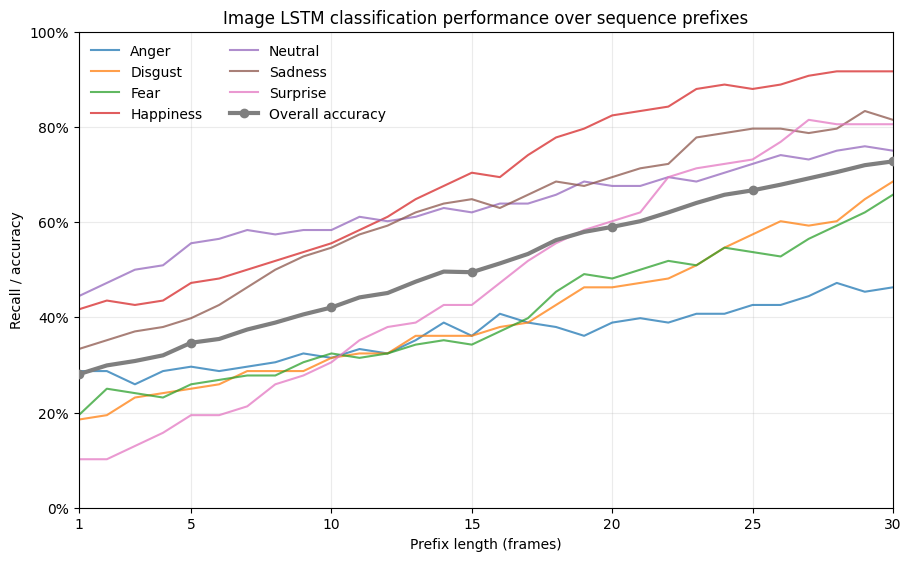

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

for k, class_name in enumerate(CLASSES):
    ax.plot(
        STEPS,
        recall[k],
        lw=1.5,
        alpha=0.75,
        label=class_name,
    )

ax.plot(
    STEPS,
    CORRECT.mean(axis=0),
    lw=3.0,
    marker='o',
    markevery=[0, 4, 9, 14, 19, 24, 29],
    label='Overall accuracy',
    zorder=10,
)

ax.set(
    title='Image LSTM classification performance over sequence prefixes',
    xlabel='Prefix length (frames)',
    ylabel='Recall / accuracy',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, frameon=False)

finish_figure(fig, '14_class_recall_and_overall_accuracy')


### 3.2 Mean true-class probability by class and overall

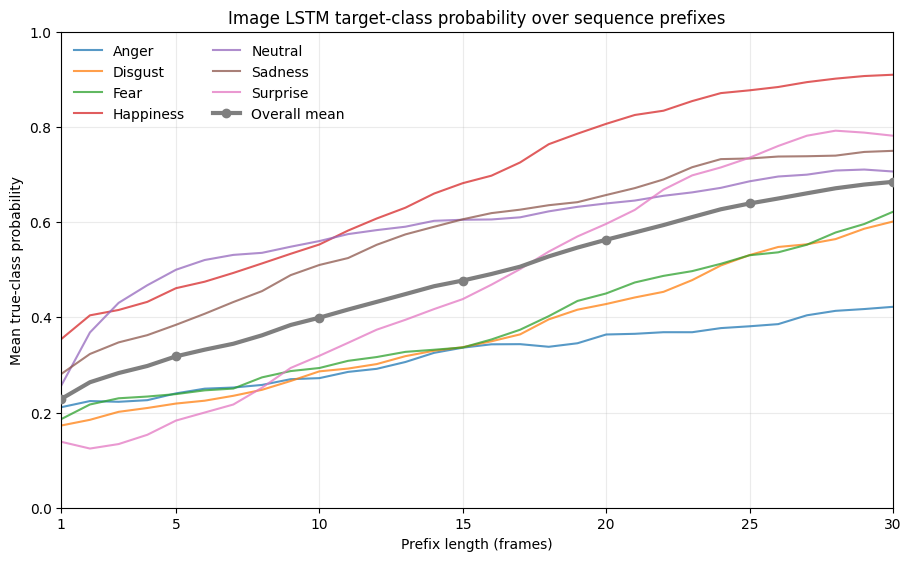

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

for k, class_name in enumerate(CLASSES):
    ax.plot(
        STEPS,
        mean_true_by_class[k],
        lw=1.5,
        alpha=0.75,
        label=class_name,
    )

ax.plot(
    STEPS,
    TRUE_P.mean(axis=0),
    lw=3.0,
    marker='o',
    markevery=[0, 4, 9, 14, 19, 24, 29],
    label='Overall mean',
    zorder=10,
)

ax.set(
    title='Image LSTM target-class probability over sequence prefixes',
    xlabel='Prefix length (frames)',
    ylabel='Mean true-class probability',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, frameon=False)

finish_figure(fig, '11_mean_true_class_probability')

pd.DataFrame({
    'prefix_length': STEPS,
    'mean_true_class_probability': TRUE_P.mean(axis=0),
}).to_csv(
    OUTPUT_DIR / 'mean_true_class_probability.csv',
    index=False,
)


### 3.3 Individual true-class probability trajectories by ground-truth class

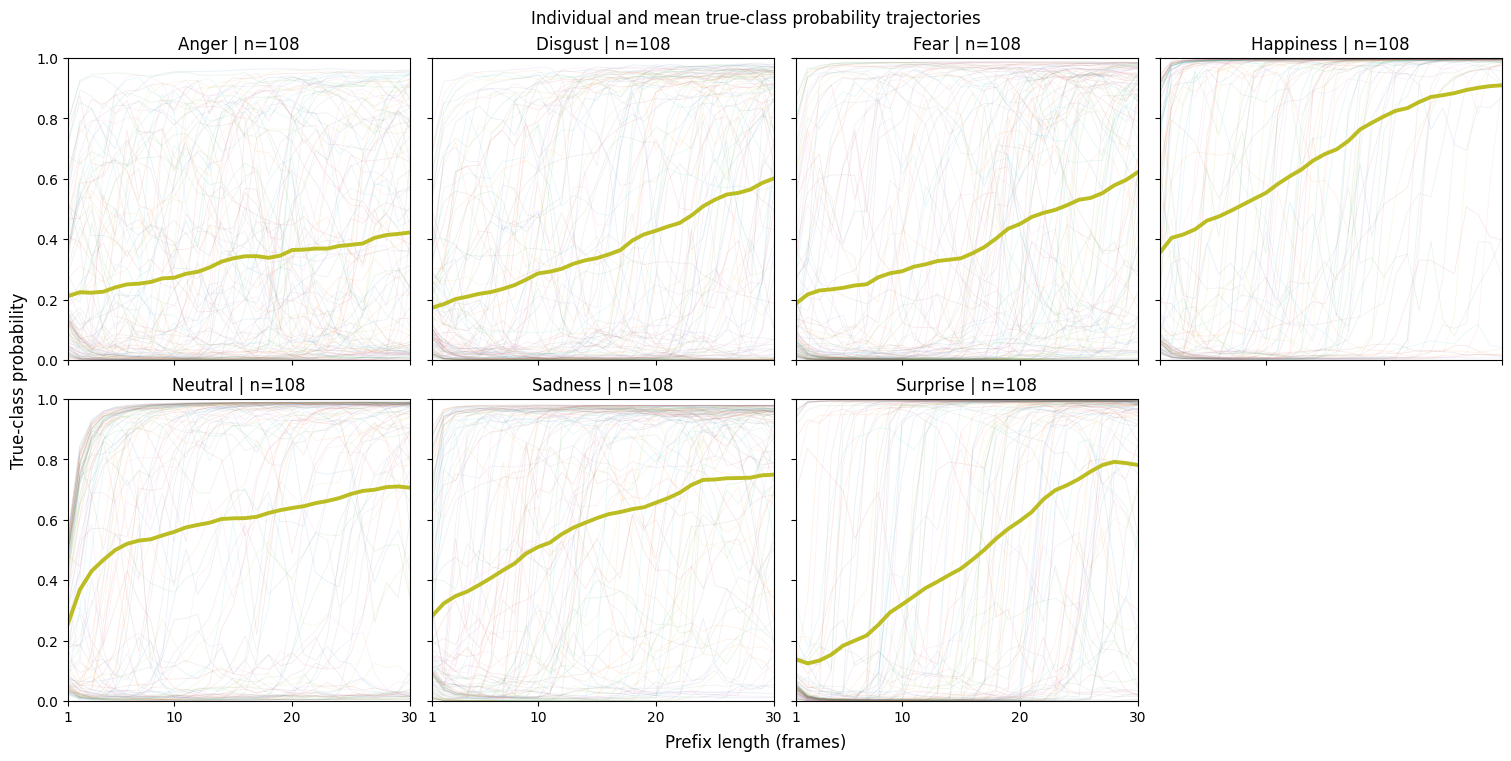

In [7]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(15, 7.5),
    sharex=True,
    sharey=True,
    layout='constrained',
)

for k, ax in enumerate(axes.flat[:7]):
    values = TRUE_P[Y == k]

    ax.plot(
        STEPS,
        values.T,
        lw=0.6,
        alpha=0.10,
    )
    ax.plot(
        STEPS,
        values.mean(axis=0),
        lw=2.8,
        label='Mean',
    )

    ax.set_title(f'{CLASSES[k]} | n={len(values)}')
    ax.set_xlim(1, 30)
    ax.set_ylim(0, 1)
    ax.set_xticks([1, 10, 20, 30])

axes.flat[7].axis('off')
fig.supxlabel('Prefix length (frames)')
fig.supylabel('True-class probability')
fig.suptitle('Individual and mean true-class probability trajectories')

finish_figure(fig, '01_class_trajectories')


### 3.4 All individual true-class trajectories

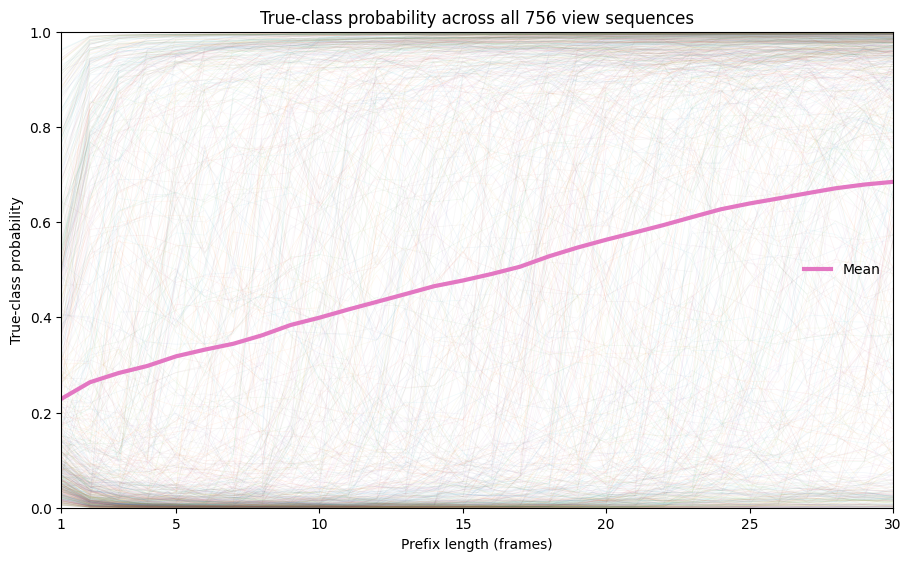

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

ax.plot(
    STEPS,
    TRUE_P.T,
    lw=0.5,
    alpha=0.06,
)

ax.plot(
    STEPS,
    TRUE_P.mean(axis=0),
    lw=3,
    label='Mean',
)

ax.set(
    title='True-class probability across all 756 view sequences',
    xlabel='Prefix length (frames)',
    ylabel='True-class probability',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)
ax.legend(frameon=False)

finish_figure(fig, '08_all_sequence_trajectories')


## 4. Trajectories grouped by final prediction outcome

### 4.1 Overall true-class trajectories: final correct vs. final wrong

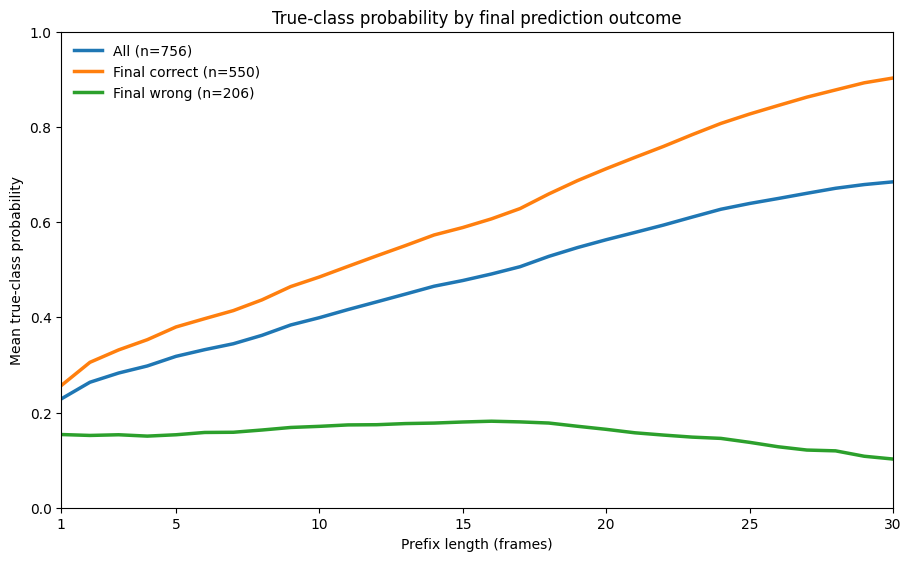

In [9]:
final_correct = CORRECT[:, -1]

fig, ax = plt.subplots(figsize=(9, 5.5), layout='constrained')

ax.plot(
    STEPS,
    TRUE_P.mean(axis=0),
    lw=2.5,
    label=f'All (n={len(Y)})',
)
ax.plot(
    STEPS,
    TRUE_P[final_correct].mean(axis=0),
    lw=2.5,
    label=f'Final correct (n={final_correct.sum()})',
)
ax.plot(
    STEPS,
    TRUE_P[~final_correct].mean(axis=0),
    lw=2.5,
    label=f'Final wrong (n={(~final_correct).sum()})',
)

ax.set(
    title='True-class probability by final prediction outcome',
    xlabel='Prefix length (frames)',
    ylabel='Mean true-class probability',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 5, 10, 15, 20, 25, 30],
)
ax.legend(frameon=False)

finish_figure(fig, '09_trajectories_by_final_outcome')


### 4.2 Class-wise true-class trajectories: final correct vs. final wrong

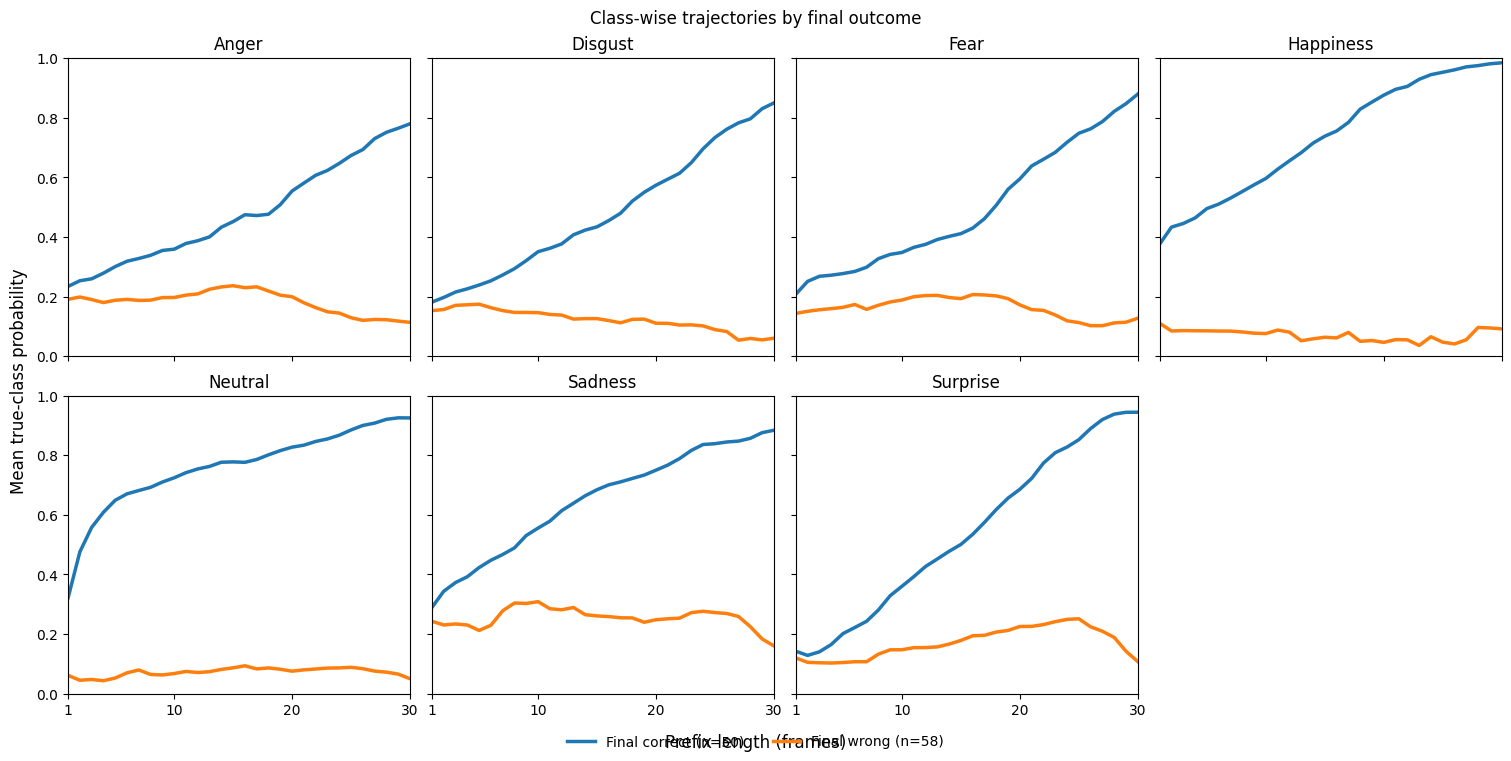

In [10]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(15, 7.5),
    sharex=True,
    sharey=True,
    layout='constrained',
)

for k, ax in enumerate(axes.flat[:7]):
    class_mask = Y == k
    good = class_mask & final_correct
    bad = class_mask & ~final_correct

    if good.any():
        ax.plot(
            STEPS,
            TRUE_P[good].mean(axis=0),
            lw=2.5,
            label=f'Final correct (n={good.sum()})',
        )

    if bad.any():
        ax.plot(
            STEPS,
            TRUE_P[bad].mean(axis=0),
            lw=2.5,
            label=f'Final wrong (n={bad.sum()})',
        )

    ax.set_title(CLASSES[k])
    ax.set_xlim(1, 30)
    ax.set_ylim(0, 1)
    ax.set_xticks([1, 10, 20, 30])

axes.flat[7].axis('off')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=2, frameon=False)
fig.supxlabel('Prefix length (frames)')
fig.supylabel('Mean true-class probability')
fig.suptitle('Class-wise trajectories by final outcome')

finish_figure(fig, '10_class_trajectories_by_final_outcome')


## 5. Recognition, confidence, prediction composition, and stability

### 5.1 Overall recognition and confidence

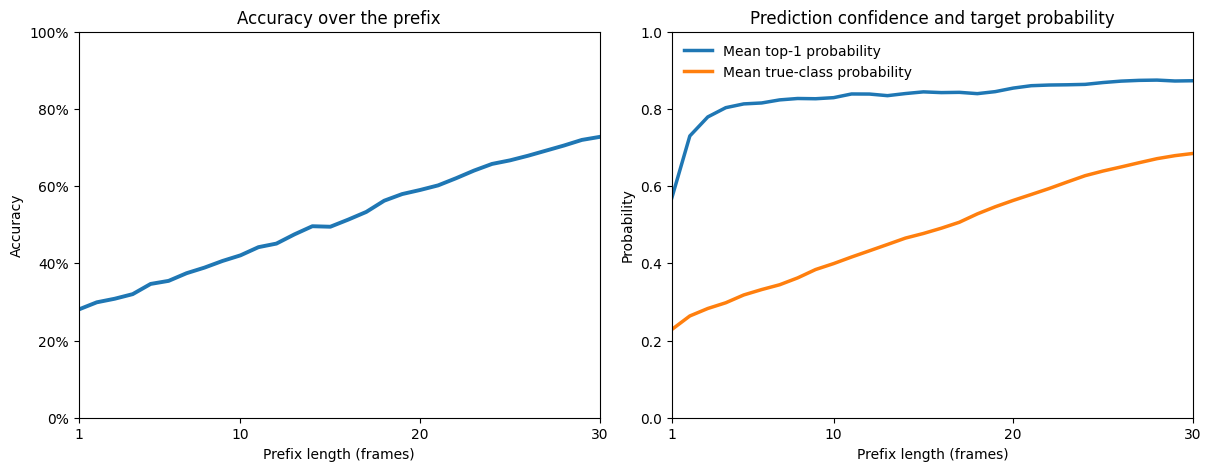

In [11]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.6),
    layout='constrained',
)

axes[0].plot(STEPS, CORRECT.mean(axis=0), lw=2.8)
axes[0].set(
    title='Accuracy over the prefix',
    xlabel='Prefix length (frames)',
    ylabel='Accuracy',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].plot(STEPS, CONF.mean(axis=0), lw=2.5, label='Mean top-1 probability')
axes[1].plot(STEPS, TRUE_P.mean(axis=0), lw=2.5, label='Mean true-class probability')
axes[1].set(
    title='Prediction confidence and target probability',
    xlabel='Prefix length (frames)',
    ylabel='Probability',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[1].legend(frameon=False)

finish_figure(fig, '02_accuracy_and_confidence')


### 5.2 Class recall heatmap and prediction composition

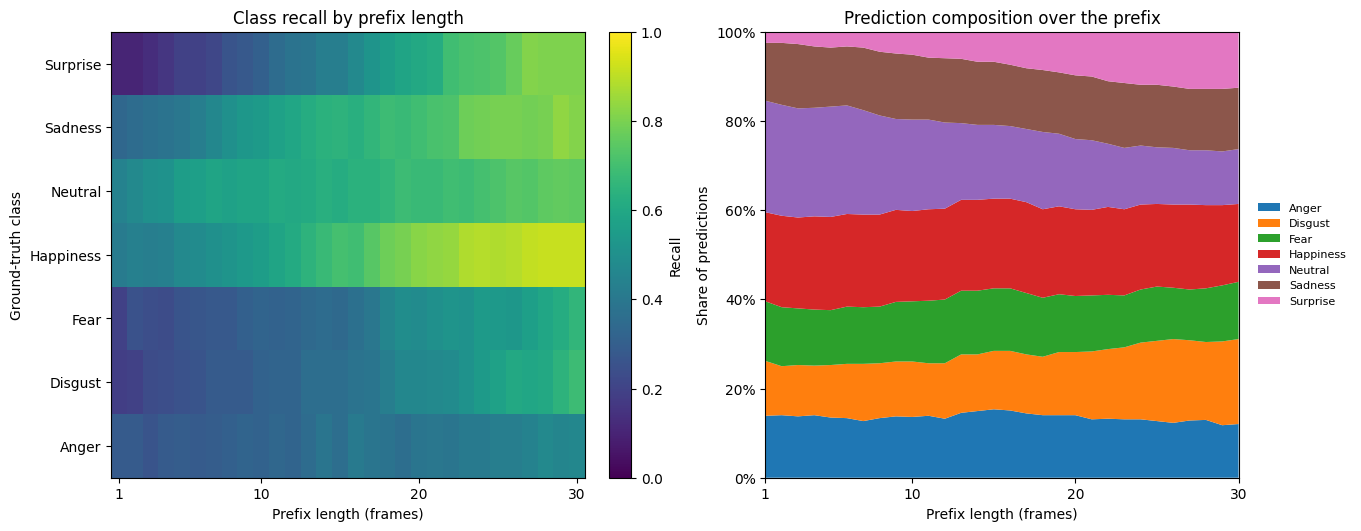

In [12]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(13.5, 5.2),
    layout='constrained',
)

im = axes[0].imshow(
    recall,
    aspect='auto',
    origin='lower',
    vmin=0,
    vmax=1,
)
axes[0].set(
    title='Class recall by prefix length',
    xlabel='Prefix length (frames)',
    ylabel='Ground-truth class',
)
axes[0].set_yticks(np.arange(7), CLASSES)
axes[0].set_xticks([0, 9, 19, 29], [1, 10, 20, 30])
fig.colorbar(im, ax=axes[0], label='Recall')

axes[1].stackplot(
    STEPS,
    *(predicted_counts[:, k] / N_SEQUENCES for k in range(N_CLASSES)),
    labels=CLASSES,
)
axes[1].set(
    title='Prediction composition over the prefix',
    xlabel='Prefix length (frames)',
    ylabel='Share of predictions',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=8,
)

finish_figure(fig, '03_class_recall_and_composition')


### 5.3 Corrections, reversals, and retrospective stability

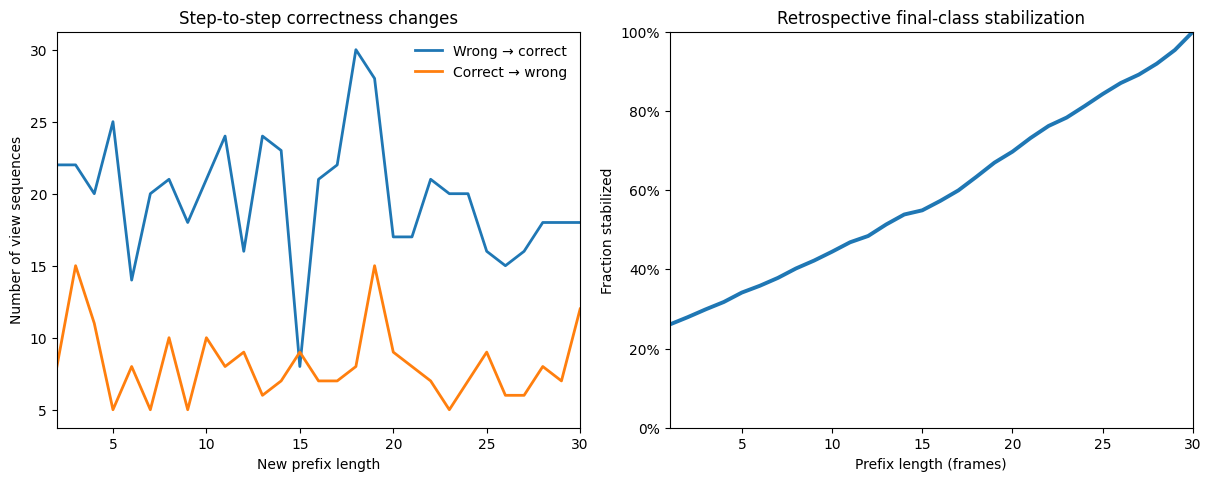

In [13]:
newly_correct = np.zeros(SEQUENCE_LENGTH, dtype=int)
newly_wrong = np.zeros(SEQUENCE_LENGTH, dtype=int)

for t in range(1, SEQUENCE_LENGTH):
    newly_correct[t] = np.sum((~CORRECT[:, t - 1]) & CORRECT[:, t])
    newly_wrong[t] = np.sum(CORRECT[:, t - 1] & (~CORRECT[:, t]))

stabilized_fraction = np.array([
    (sequence_summary['stabilization_timestep'] <= t).mean()
    for t in STEPS
])

recovery_df = pd.DataFrame({
    'prefix_length': STEPS,
    'newly_correct_vs_previous_prefix': newly_correct,
    'newly_wrong_vs_previous_prefix': newly_wrong,
    'fraction_final_class_stabilized': stabilized_fraction,
})
recovery_df.to_csv(TABLE_DIR / 'recovery_and_stability.csv', index=False)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.7),
    layout='constrained',
)

axes[0].plot(STEPS[1:], newly_correct[1:], lw=2, label='Wrong → correct')
axes[0].plot(STEPS[1:], newly_wrong[1:], lw=2, label='Correct → wrong')
axes[0].set(
    title='Step-to-step correctness changes',
    xlabel='New prefix length',
    ylabel='Number of view sequences',
    xlim=(2, 30),
)
axes[0].legend(frameon=False)

axes[1].plot(STEPS, stabilized_fraction, lw=2.8)
axes[1].set(
    title='Retrospective final-class stabilization',
    xlabel='Prefix length (frames)',
    ylabel='Fraction stabilized',
    xlim=(1, 30),
    ylim=(0, 1),
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

finish_figure(fig, '04_corrections_and_stability')


### 5.4 Confusion matrices at fixed descriptive checkpoints

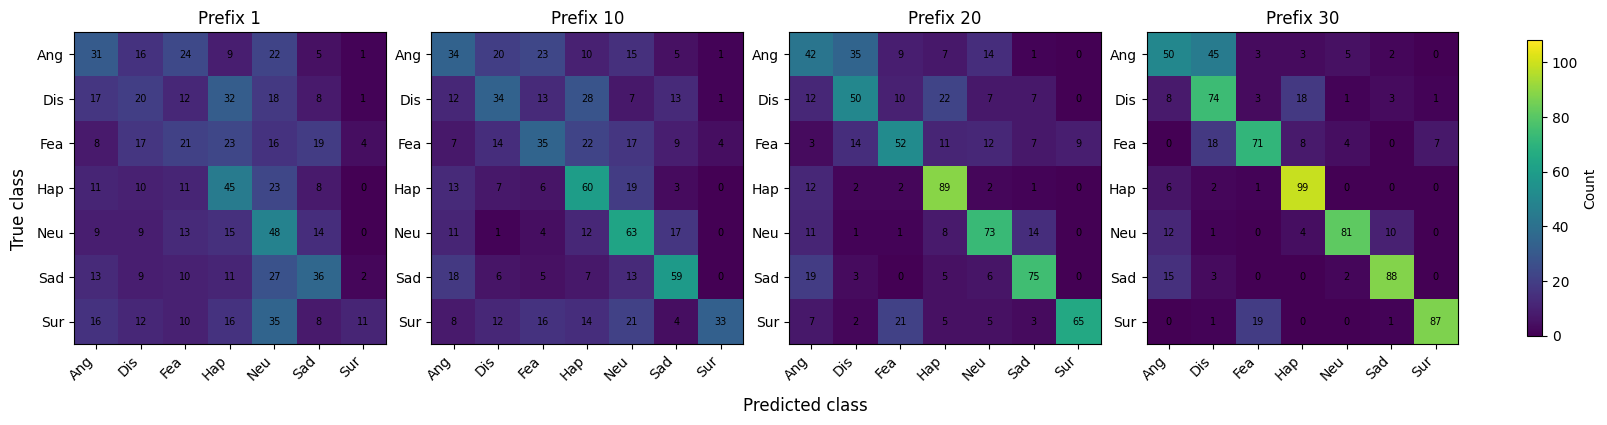

In [14]:
checkpoints = [1, 10, 20, 30]
confusion_rows = []

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4.2),
    layout='constrained',
)

for ax, prefix in zip(axes, checkpoints):
    pred = PRED[:, prefix - 1]
    cm = np.zeros((7, 7), dtype=int)
    np.add.at(cm, (Y, pred), 1)

    for i in range(7):
        for j in range(7):
            confusion_rows.append({
                'prefix_length': prefix,
                'true_class': CLASSES[i],
                'predicted_class': CLASSES[j],
                'count': int(cm[i, j]),
            })

    im = ax.imshow(cm, vmin=0, vmax=108)
    ax.set_title(f'Prefix {prefix}')
    ax.set_xticks(np.arange(7), [c[:3] for c in CLASSES], rotation=45, ha='right')
    ax.set_yticks(np.arange(7), [c[:3] for c in CLASSES])

    for i in range(7):
        for j in range(7):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=7)

fig.supxlabel('Predicted class')
fig.supylabel('True class')
fig.colorbar(im, ax=axes, label='Count', shrink=0.8)

pd.DataFrame(confusion_rows).to_csv(
    TABLE_DIR / 'confusions_at_fixed_prefixes.csv',
    index=False,
)

finish_figure(fig, '05_error_patterns')


## 6. Individual examples and participant-level descriptive checks

### 6.1 Reproducibly selected individual examples

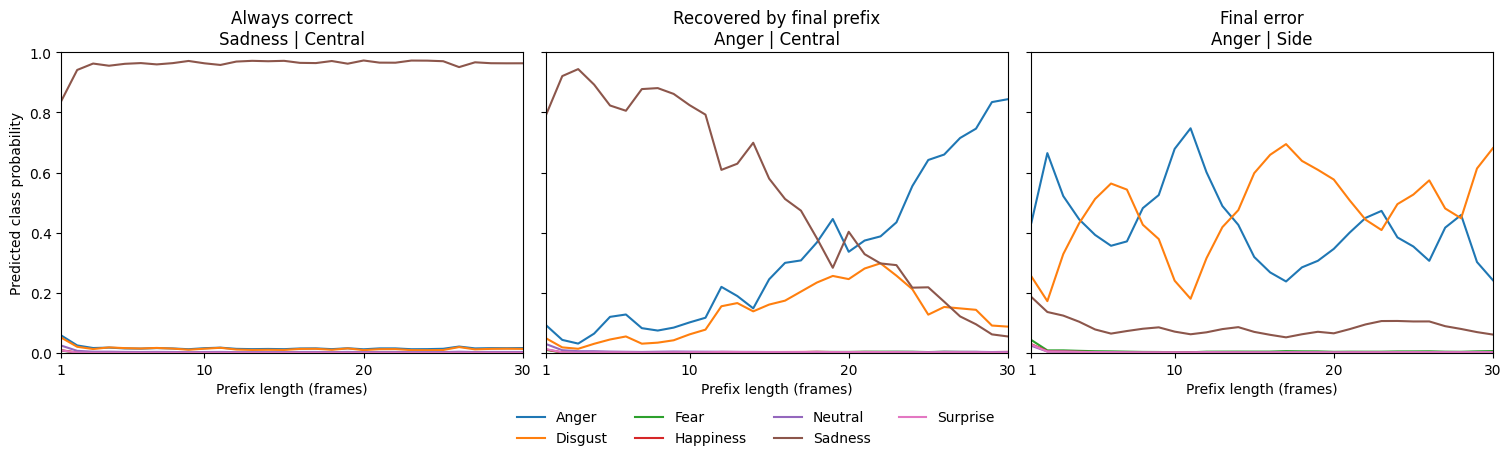

In [15]:
example_groups = {
    'Always correct': np.where(CORRECT.all(axis=1))[0],
    'Recovered by final prefix': np.where((~CORRECT[:, 0]) & CORRECT[:, -1])[0],
    'Final error': np.where(~CORRECT[:, -1])[0],
}

selected = []

for label, indices in example_groups.items():
    if len(indices):
        selected.append((label, int(indices[0])))

selected_rows = []

fig, axes = plt.subplots(
    1, len(selected),
    figsize=(5 * len(selected), 4.5),
    sharex=True,
    sharey=True,
    layout='constrained',
)

if len(selected) == 1:
    axes = [axes]

for ax, (label, i) in zip(axes, selected):
    for k, class_name in enumerate(CLASSES):
        ax.plot(STEPS, P[i, :, k], lw=1.5, label=class_name)

    ax.set(
        title=(
            f'{label}\n'
            f'{CLASSES[Y[i]]} | {metadata.iloc[i]["perspective"]}'
        ),
        xlabel='Prefix length (frames)',
        xlim=(1, 30),
        ylim=(0, 1),
        xticks=[1, 10, 20, 30],
    )

    selected_rows.append({
        'group': label,
        'sequence_id': sequence_ids[i],
        'reenactment_id': metadata.iloc[i]['reenactment_id'],
        'perspective': metadata.iloc[i]['perspective'],
        'true_class': CLASSES[Y[i]],
        'final_predicted_class': CLASSES[PRED[i, -1]],
        'final_correct': bool(CORRECT[i, -1]),
    })

axes[0].set_ylabel('Predicted class probability')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=4, frameon=False)

pd.DataFrame(selected_rows).to_csv(
    TABLE_DIR / 'selected_examples.csv',
    index=False,
)

finish_figure(fig, '06_selected_examples')


### 6.2 Participant-level descriptive check

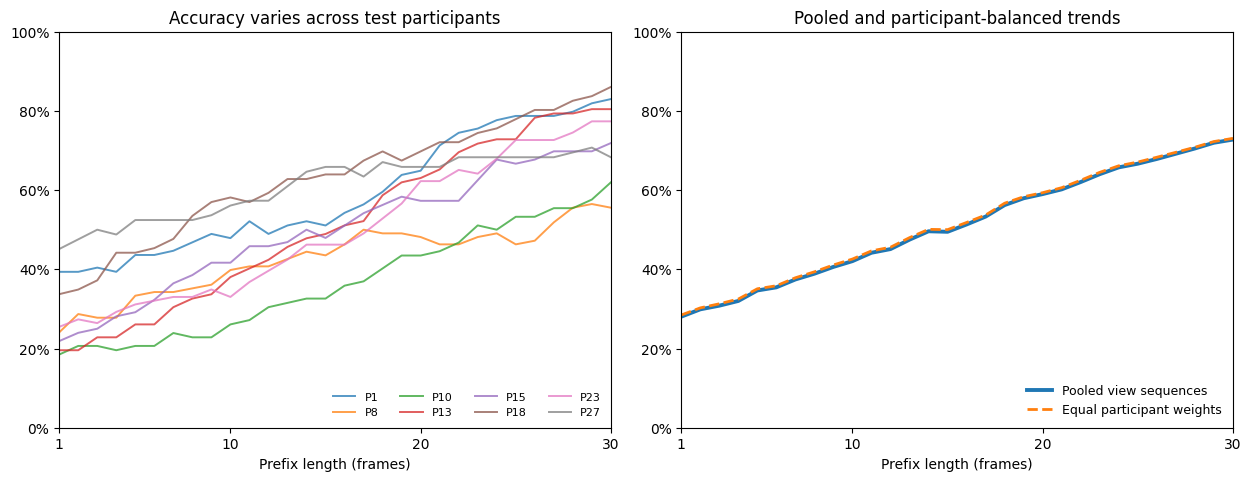

Participants improving from prefix 1 to 30: 8/8
Maximum pooled vs. equal-participant accuracy difference: 0.536 pp


In [16]:
participants = np.sort(metadata['participant_id'].unique())

participant_acc = np.array([
    CORRECT[
        metadata['participant_id'].eq(pid).to_numpy()
    ].mean(axis=0)
    for pid in participants
])

participant_rows = []

for pid, values in zip(participants, participant_acc):
    mask = metadata['participant_id'].eq(pid).to_numpy()

    for t, value in zip(STEPS, values):
        participant_rows.append({
            'participant_id': int(pid),
            'n_view_sequences': int(mask.sum()),
            'prefix_length': int(t),
            'accuracy': float(value),
        })

participant_df = pd.DataFrame(participant_rows)

participant_df.to_csv(
    TABLE_DIR / 'participant_accuracy_by_prefix.csv',
    index=False,
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.4, 4.7),
    layout='constrained',
)

for pid, values in zip(participants, participant_acc):
    axes[0].plot(
        STEPS,
        values,
        lw=1.4,
        alpha=0.75,
        label=f'P{pid}',
    )

axes[0].set(
    title='Accuracy varies across test participants',
    xlabel='Prefix length (frames)',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[0].legend(ncol=4, loc='lower right', fontsize=8, frameon=False)

axes[1].plot(
    STEPS,
    CORRECT.mean(axis=0),
    lw=2.8,
    label='Pooled view sequences',
)
axes[1].plot(
    STEPS,
    participant_acc.mean(axis=0),
    lw=2,
    ls='--',
    label='Equal participant weights',
)

axes[1].set(
    title='Pooled and participant-balanced trends',
    xlabel='Prefix length (frames)',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[1].legend(loc='lower right', frameon=False, fontsize=9)

for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))

finish_figure(fig, '07_participant_check')

print(
    'Participants improving from prefix 1 to 30:',
    f'{(participant_acc[:, -1] > participant_acc[:, 0]).sum()}/{len(participants)}',
)
print(
    'Maximum pooled vs. equal-participant accuracy difference:',
    f'{100 * np.abs(participant_acc.mean(axis=0) - CORRECT.mean(axis=0)).max():.3f} pp',
)


## 7. View-specific analysis

Central and Side sequences are predictions from the same reenactments and are therefore paired. The following plots are descriptive and preserve that pairing where relevant.

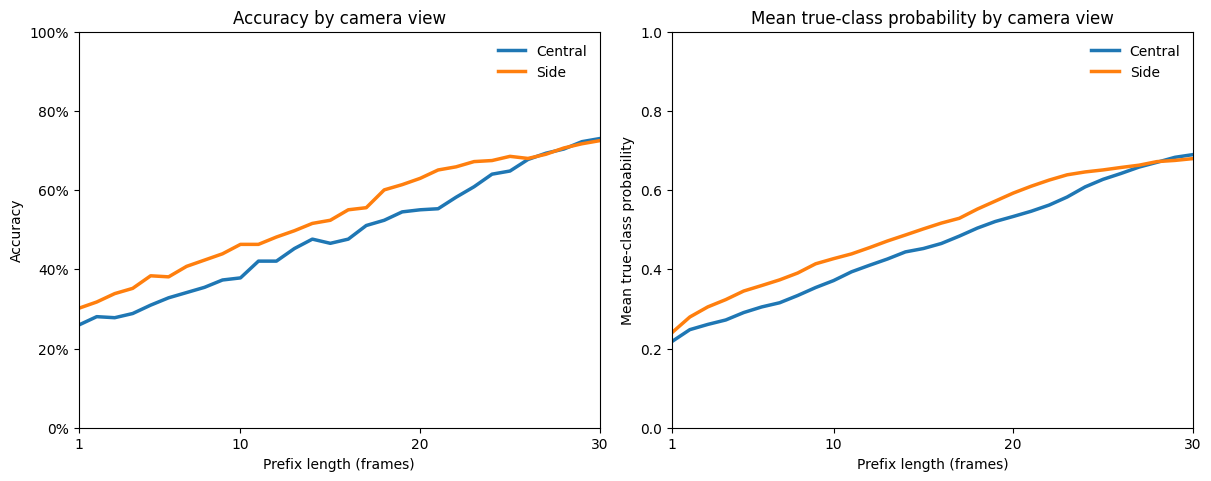

In [17]:
perspective_rows = []

for perspective in ['Central', 'Side']:
    mask = metadata['perspective'].eq(perspective).to_numpy()

    for t in range(SEQUENCE_LENGTH):
        perspective_rows.append({
            'perspective': perspective,
            'prefix_length': t + 1,
            'n_sequences': int(mask.sum()),
            'accuracy': float(CORRECT[mask, t].mean()),
            'mean_true_probability': float(TRUE_P[mask, t].mean()),
            'mean_confidence': float(CONF[mask, t].mean()),
        })

perspective_df = pd.DataFrame(perspective_rows)
perspective_df.to_csv(TABLE_DIR / 'perspective_by_prefix.csv', index=False)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.7),
    layout='constrained',
)

for perspective in ['Central', 'Side']:
    sub = perspective_df[perspective_df['perspective'] == perspective]

    axes[0].plot(
        sub['prefix_length'],
        sub['accuracy'],
        lw=2.5,
        label=perspective,
    )
    axes[1].plot(
        sub['prefix_length'],
        sub['mean_true_probability'],
        lw=2.5,
        label=perspective,
    )

axes[0].set(
    title='Accuracy by camera view',
    xlabel='Prefix length (frames)',
    ylabel='Accuracy',
    xlim=(1, 30),
    ylim=(0, 1),
)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))

axes[1].set(
    title='Mean true-class probability by camera view',
    xlabel='Prefix length (frames)',
    ylabel='Mean true-class probability',
    xlim=(1, 30),
    ylim=(0, 1),
)

for ax in axes:
    ax.set_xticks([1, 10, 20, 30])
    ax.legend(frameon=False)

finish_figure(fig, '15_perspective_trajectories')


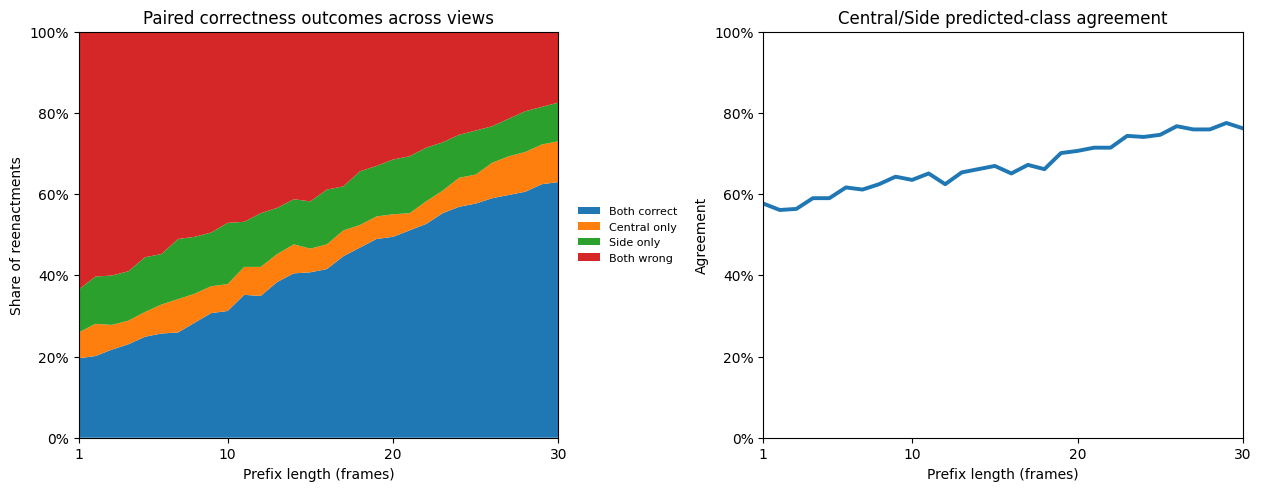

In [18]:
paired_correct = df.pivot_table(
    index=['reenactment_id', 'timestep'],
    columns='perspective',
    values='correct_at_timestep',
    aggfunc='first',
)

paired_pred = df.pivot_table(
    index=['reenactment_id', 'timestep'],
    columns='perspective',
    values='predicted_class_id',
    aggfunc='first',
)

paired_rows = []

for t in STEPS:
    correctness = paired_correct.xs(t, level='timestep')
    predictions = paired_pred.xs(t, level='timestep')

    both_correct = correctness['Central'] & correctness['Side']
    central_only = correctness['Central'] & ~correctness['Side']
    side_only = ~correctness['Central'] & correctness['Side']
    both_wrong = ~correctness['Central'] & ~correctness['Side']

    paired_rows.append({
        'prefix_length': int(t),
        'both_correct': float(both_correct.mean()),
        'central_only_correct': float(central_only.mean()),
        'side_only_correct': float(side_only.mean()),
        'both_wrong': float(both_wrong.mean()),
        'same_predicted_class': float(
            (predictions['Central'] == predictions['Side']).mean()
        ),
    })

paired_view_df = pd.DataFrame(paired_rows)
paired_view_df.to_csv(TABLE_DIR / 'paired_view_outcomes_by_prefix.csv', index=False)

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 4.8),
    layout='constrained',
)

axes[0].stackplot(
    paired_view_df['prefix_length'],
    paired_view_df['both_correct'],
    paired_view_df['central_only_correct'],
    paired_view_df['side_only_correct'],
    paired_view_df['both_wrong'],
    labels=[
        'Both correct',
        'Central only',
        'Side only',
        'Both wrong',
    ],
)
axes[0].set(
    title='Paired correctness outcomes across views',
    xlabel='Prefix length (frames)',
    ylabel='Share of reenactments',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)

axes[1].plot(
    paired_view_df['prefix_length'],
    paired_view_df['same_predicted_class'],
    lw=2.8,
)
axes[1].set(
    title='Central/Side predicted-class agreement',
    xlabel='Prefix length (frames)',
    ylabel='Agreement',
    xlim=(1, 30),
    ylim=(0, 1),
    xticks=[1, 10, 20, 30],
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))

finish_figure(fig, '16_paired_view_correctness')


## 8. Detailed class-probability views

### 8.1 Shared plotting helpers

In [19]:
def configure_probability_axis(ax):
    ax.set(
        xlim=(1, 30),
        ylim=(-0.025, 1.025),
        xticks=[1, 10, 20, 30],
    )


def probability_panel(
    ax,
    true_class_id,
    mask,
    individuals=False,
    error_individuals=False,
):
    count = int(mask.sum())

    ax.set_title(f'{CLASSES[true_class_id]} | n = {count}')
    configure_probability_axis(ax)

    if count == 0:
        ax.text(
            0.5,
            0.5,
            'No final errors\nMean trajectories undefined',
            transform=ax.transAxes,
            ha='center',
            va='center',
        )
        return

    values = P[mask]

    if error_individuals:
        true_lines = values[:, :, true_class_id]
        final_labels = PRED[mask, -1]

        assert np.all(final_labels != true_class_id)

        predicted_lines = np.take_along_axis(
            values,
            final_labels[:, None, None],
            axis=2,
        ).squeeze(axis=2)

        ax.plot(
            STEPS,
            true_lines.T,
            alpha=0.10,
            lw=0.7,
        )
        ax.plot(
            STEPS,
            predicted_lines.T,
            alpha=0.10,
            lw=0.7,
        )

    if individuals:
        for j in range(7):
            ax.plot(
                STEPS,
                values[:, :, j].T,
                lw=0.5,
                alpha=0.035 if j != true_class_id else 0.07,
            )

    means = values.mean(axis=0)

    for j in [i for i in range(7) if i != true_class_id] + [true_class_id]:
        ax.plot(
            STEPS,
            means[:, j],
            lw=3.0 if j == true_class_id else 1.4,
            ls='-' if j == true_class_id else '--',
            label=CLASSES[j],
        )


def export_probability_family(errors_only, prefix):
    for k in range(7):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if errors_only
                else np.ones(len(Y), dtype=bool)
            )
        )

        fig, ax = plt.subplots(figsize=(8.8, 5.4), layout='constrained')

        probability_panel(
            ax,
            k,
            mask,
            individuals=not errors_only,
            error_individuals=errors_only,
        )

        ax.set(
            xlabel='Prefix length (frames)',
            ylabel='Predicted class probability',
        )
        ax.legend(ncol=3, frameon=False, fontsize=8)

        fig.suptitle(
            'Final errors only'
            if errors_only
            else 'All view sequences of the ground-truth class',
            fontsize=12,
        )

        finish_figure(
            fig,
            f'{prefix}_{CLASSES[k].lower()}',
            show=False,
        )

    fig, axes = plt.subplots(
        2, 4,
        figsize=(15.2, 7.6),
        sharex=True,
        sharey=True,
        layout='constrained',
    )

    for k, ax in enumerate(axes.flat[:7]):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if errors_only
                else np.ones(len(Y), dtype=bool)
            )
        )

        probability_panel(
            ax,
            k,
            mask,
            individuals=False,
            error_individuals=False,
        )

    legend_ax = axes.flat[7]
    legend_ax.axis('off')

    handles, labels = axes.flat[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc='upper left', ncol=2, frameon=False)

    note = (
        'Solid thick mean: ground-truth class\n'
        'Dashed means: other classes\n'
        + (
            'Groups: wrong at prefix 30'
            if errors_only
            else 'Class-conditional means over all view sequences'
        )
    )

    legend_ax.text(
        0.04,
        0.15,
        note,
        transform=legend_ax.transAxes,
        fontsize=9,
    )

    fig.supxlabel('Prefix length (frames)')
    fig.supylabel('Predicted class probability')

    fig.suptitle(
        'Final errors: mean output probabilities'
        if errors_only
        else 'Output probabilities within each ground-truth class',
        fontsize=14,
    )

    finish_figure(fig, prefix + '_overview')


### 8.2 All seven output probabilities within each ground-truth class

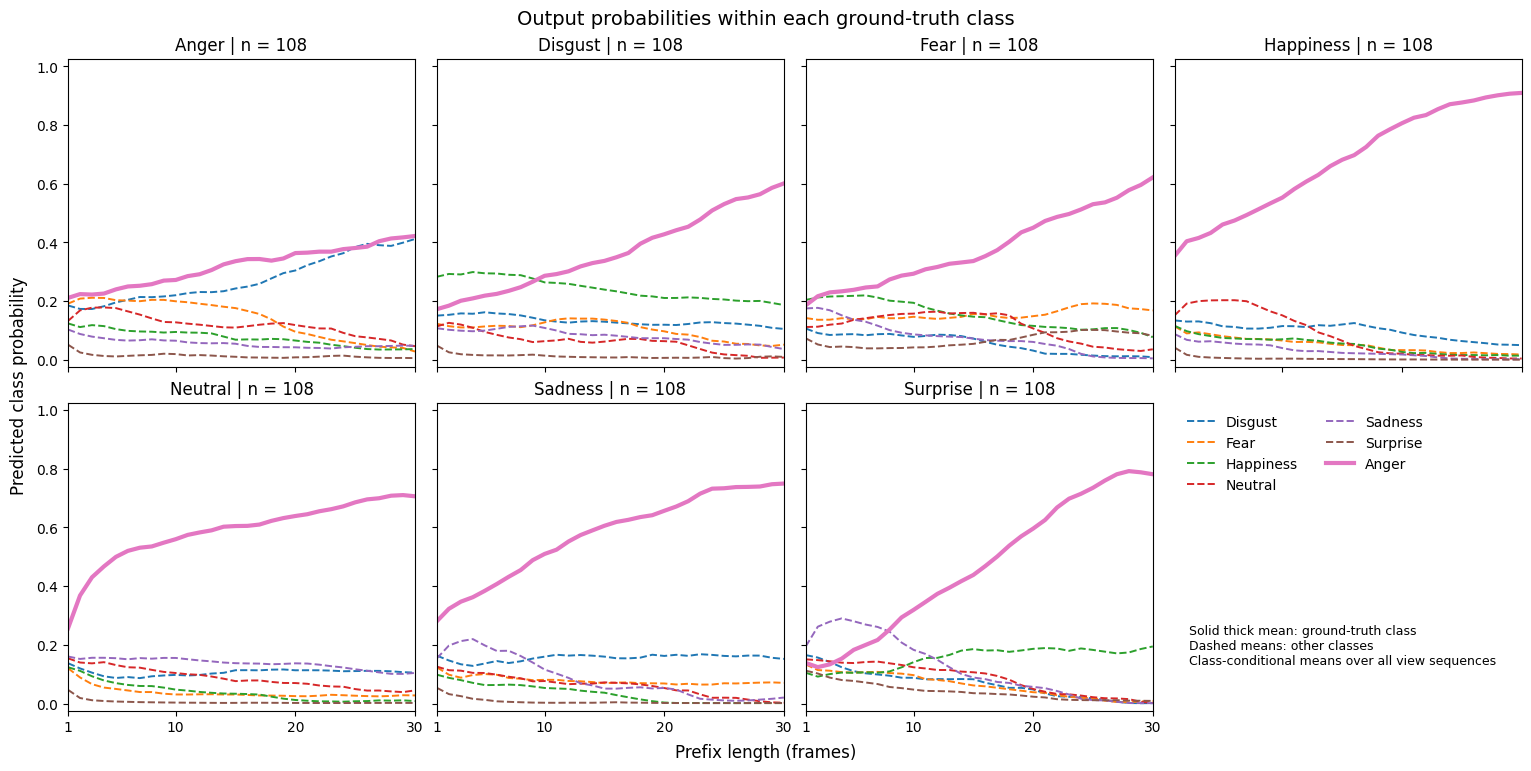

In [20]:
export_probability_family(
    errors_only=False,
    prefix='12_all_class_probabilities',
)


### 8.3 Final errors: output probabilities within each ground-truth class

Final-error counts by class: {'Anger': 58, 'Disgust': 34, 'Fear': 37, 'Happiness': 9, 'Neutral': 27, 'Sadness': 20, 'Surprise': 21}


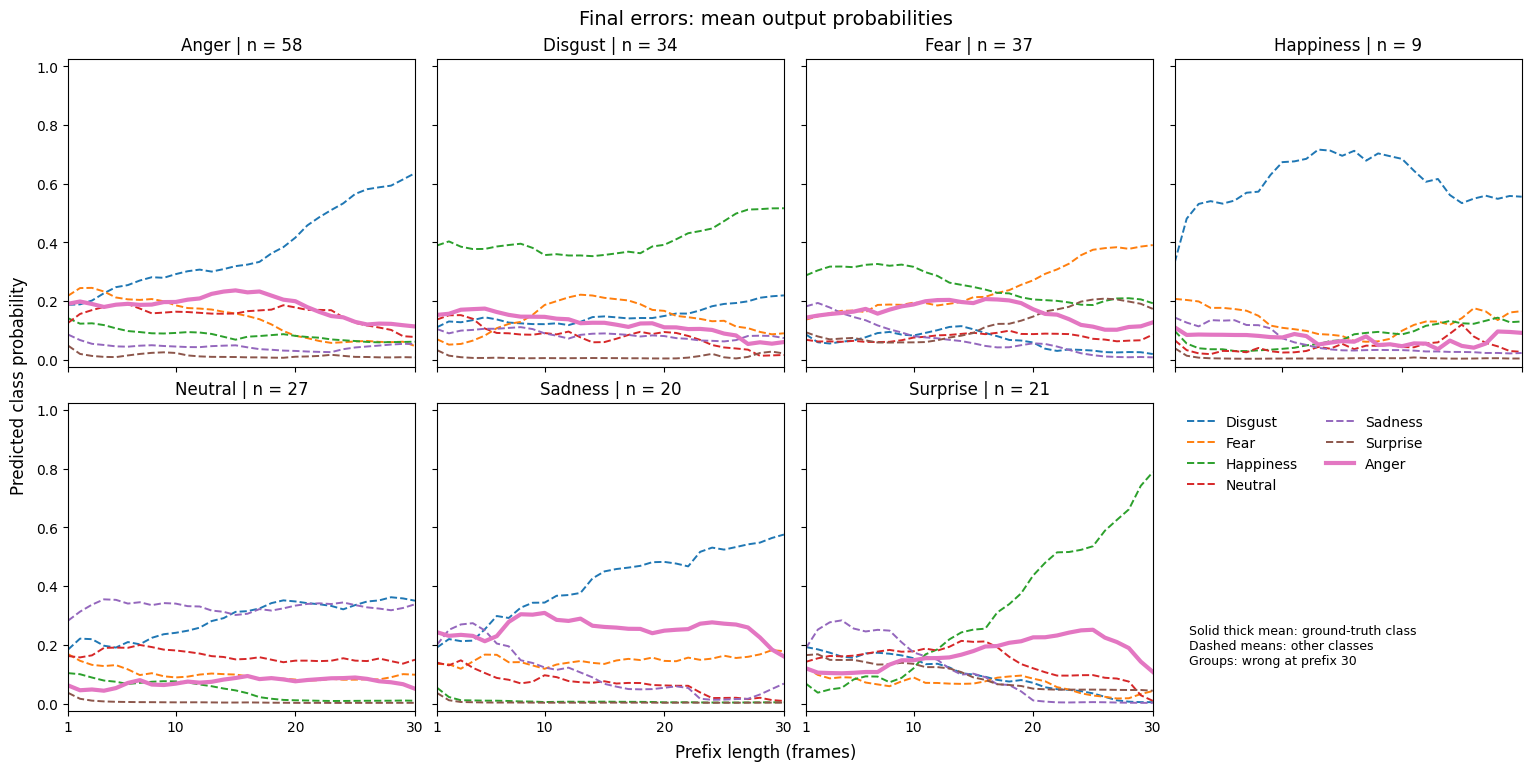

In [21]:
error_counts = {
    CLASSES[k]: int(((Y == k) & ~final_correct).sum())
    for k in range(7)
}

print('Final-error counts by class:', error_counts)

export_probability_family(
    errors_only=True,
    prefix='13_final_error_probabilities',
)


### 8.4 Export class-conditional probability means

In [22]:
rows = []

for subset in ['all', 'final_errors']:
    for k in range(7):
        mask = (
            (Y == k)
            & (
                ~final_correct
                if subset == 'final_errors'
                else np.ones(len(Y), dtype=bool)
            )
        )

        n = int(mask.sum())

        means = (
            P[mask].mean(axis=0)
            if n
            else np.full((SEQUENCE_LENGTH, 7), np.nan)
        )

        if n:
            assert np.allclose(means.sum(axis=1), 1, atol=1e-6)

        for t in range(SEQUENCE_LENGTH):
            for j in range(7):
                rows.append({
                    'subset': subset,
                    'true_class': CLASSES[k],
                    'output_class': CLASSES[j],
                    'prefix_length': t + 1,
                    'n_sequences': n,
                    'mean_probability': means[t, j],
                })

means_df = pd.DataFrame(rows)

means_df.to_csv(
    OUTPUT_DIR / 'class_conditional_probability_means.csv',
    index=False,
)

print(f'Exported {len(means_df):,} class-conditional mean rows.')


Exported 2,940 class-conditional mean rows.


## 9. Results report and provenance

In [23]:
def markdown_table(table):
    cols = [str(c) for c in table.columns]
    lines = [
        '| ' + ' | '.join(cols) + ' |',
        '| ' + ' | '.join(['---'] * len(cols)) + ' |',
    ]

    for row in table.itertuples(index=False, name=None):
        lines.append('| ' + ' | '.join(str(v) for v in row) + ' |')

    return '\n'.join(lines)


checkpoint_table = pd.DataFrame({
    'Prefix': [1, 5, 10, 15, 20, 25, 30],
    'Correct / 756': [
        f'{int(overall.loc[t - 1, "n_correct"])}/756'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
    'Accuracy': [
        f'{overall.loc[t - 1, "accuracy"]:.2%}'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
    'Mean true-class probability': [
        f'{overall.loc[t - 1, "mean_true_probability"]:.3f}'
        for t in [1, 5, 10, 15, 20, 25, 30]
    ],
})

class_table = pd.DataFrame({
    'Class': CLASSES,
    'Recall, 1 frame': [f'{v:.2%}' for v in recall[:, 0]],
    'Recall, 30 frames': [f'{v:.2%}' for v in recall[:, -1]],
    'Final errors': [
        int(((Y == k) & ~final_correct).sum())
        for k in range(7)
    ],
})

view_table = perspective_df[
    perspective_df['prefix_length'].isin([1, 10, 20, 30])
].copy()

view_table['accuracy'] = view_table['accuracy'].map(lambda x: f'{x:.2%}')
view_table['mean_true_probability'] = view_table['mean_true_probability'].map(
    lambda x: f'{x:.3f}'
)
view_table = view_table[
    ['perspective', 'prefix_length', 'accuracy', 'mean_true_probability']
]

final_cm = np.zeros((7, 7), dtype=int)
np.add.at(final_cm, (Y, PRED[:, -1]), 1)

error_pairs = sorted(
    [
        (int(final_cm[i, j]), CLASSES[i], CLASSES[j])
        for i in range(7)
        for j in range(7)
        if i != j
    ],
    reverse=True,
)

error_text = '; '.join(
    f'{a} → {b}: {n}'
    for n, a, b in error_pairs[:4]
)

final_predicted_class = PRED[:, -1]
final_predicted_probability = np.take_along_axis(
    P,
    final_predicted_class[:, None, None],
    axis=2,
).squeeze(axis=2)

competition_rows = []

for k, class_name in enumerate(CLASSES):
    mask = Y == k
    final_mean = P[mask, -1].mean(axis=0)
    competitors = [j for j in range(7) if j != k]
    strongest_competitor = max(competitors, key=lambda j: final_mean[j])

    competition_rows.append({
        'True class': class_name,
        'Mean true-class p, prefix 30': f'{final_mean[k]:.3f}',
        'Strongest competing class': CLASSES[strongest_competitor],
        'Mean competing p, prefix 30': f'{final_mean[strongest_competitor]:.3f}',
    })

competition_table = pd.DataFrame(competition_rows)

pair30 = paired_view_df.loc[
    paired_view_df['prefix_length'] == 30
].iloc[0]

sections = []

def section(title, text, table=None, figure=None, caption=None):
    sections.append({
        'title': title,
        'text': text,
        'table': table,
        'figure': figure,
        'caption': caption,
    })


section(
    'Main findings',
    f'The ordered image LSTM becomes more accurate as it receives longer prefixes: '
    f'{CORRECT[:, 0].sum()}/756 ({CORRECT[:, 0].mean():.2%}) after one frame and '
    f'{CORRECT[:, -1].sum()}/756 ({CORRECT[:, -1].mean():.2%}) after 30 frames. '
    f'The increase is {100 * (CORRECT[:, -1].mean() - CORRECT[:, 0].mean()):.2f} percentage points. '
    'This is an exploratory within-model prefix analysis, not a comparison with a separately trained static image model.',
    checkpoint_table,
    '14_class_recall_and_overall_accuracy',
    'Class-specific recall trajectories with overall accuracy emphasized.',
)

section(
    'Class-specific trajectories',
    'The classes benefit differently from additional frames. Happiness reaches the highest final recall, '
    'while Anger remains the most difficult class. Surprise starts especially low and improves strongly over the sequence. '
    'The probability trajectories reveal the same heterogeneous evidence accumulation.',
    class_table,
    '11_mean_true_class_probability',
    'Mean probability of the ground-truth class for each expression and across all expressions.',
)

section(
    'Final successes and final errors diverge',
    f'For the {int(final_correct.sum())} final successes, mean true-class probability rises from '
    f'{TRUE_P[final_correct, 0].mean():.3f} to {TRUE_P[final_correct, -1].mean():.3f}. '
    f'For the {int((~final_correct).sum())} final errors, it changes from '
    f'{TRUE_P[~final_correct, 0].mean():.3f} to {TRUE_P[~final_correct, -1].mean():.3f}, '
    f'while mean maximum probability among final errors increases from '
    f'{CONF[~final_correct, 0].mean():.3f} to {CONF[~final_correct, -1].mean():.3f}. '
    'Final errors therefore often become confident incorrect decisions rather than remaining uniformly uncertain.',
    figure='09_trajectories_by_final_outcome',
    caption='Mean true-class probability for all view sequences, final successes, and final errors.',
)

section(
    'Competing class hypotheses',
    'The seven-output probability trajectories reveal which alternatives remain competitive as more frames are observed. '
    'At the final prefix, Anger remains closely opposed by Disgust, while Surprise remains most strongly opposed by Fear. '
    f'The most frequent final errors are {error_text}.',
    competition_table,
    '12_all_class_probabilities_overview',
    'Mean output probabilities within each ground-truth class across the 30 frame prefixes.',
)

section(
    'Camera-view trajectories',
    f'Central and Side views show similar full-sequence accuracy: '
    f'{CORRECT[metadata["perspective"].eq("Central").to_numpy(), -1].mean():.2%} Central and '
    f'{CORRECT[metadata["perspective"].eq("Side").to_numpy(), -1].mean():.2%} Side. '
    'The Side view is more accurate over much of the early and middle prefix, while the Central view catches up by the final prefix. '
    'Because the two sequences originate from the same reenactments, this comparison is descriptive and paired.',
    view_table,
    '15_perspective_trajectories',
    'Accuracy and mean true-class probability for Central and Side image sequences.',
)

section(
    'Paired Central/Side outcomes',
    f'At prefix 30, both views are correct for {pair30["both_correct"]:.2%} of reenactments; '
    f'Central alone is correct for {pair30["central_only_correct"]:.2%}, '
    f'Side alone for {pair30["side_only_correct"]:.2%}, and both are wrong for {pair30["both_wrong"]:.2%}. '
    f'The two views predict the same class for {pair30["same_predicted_class"]:.2%} of reenactments at prefix 30. '
    'This shows that the two viewpoints remain partly complementary even though their aggregate accuracies are nearly identical.',
    figure='16_paired_view_correctness',
    caption='Paired correctness outcomes and predicted-class agreement between Central and Side views.',
)

section(
    'Probability dynamics within final errors',
    f'Across the {int((~final_correct).sum())} final errors, the mean probability assigned to the eventual wrong class '
    f'increases from {final_predicted_probability[~final_correct, 0].mean():.3f} at one frame '
    f'to {final_predicted_probability[~final_correct, -1].mean():.3f} at 30 frames. '
    f'Over the same interval, mean probability assigned to the true class changes from '
    f'{TRUE_P[~final_correct, 0].mean():.3f} to {TRUE_P[~final_correct, -1].mean():.3f}.',
    figure='13_final_error_probabilities_overview',
    caption='Mean output probabilities within each ground-truth class, restricted to final errors.',
)


report_lines = [
    '# Image Prediction Trajectory Analysis',
    '',
    'This report summarizes the main descriptive results from the ordered image-LSTM prefix analysis.',
    '',
]

for item in sections:
    report_lines += [
        f'## {item["title"]}',
        '',
        item['text'],
        '',
    ]

    if item['table'] is not None:
        report_lines += [markdown_table(item['table']), '']

    if item['figure'] is not None:
        report_lines += [
            f'Figure: `figures/{item["figure"]}.png`',
            '',
        ]

    if item['caption']:
        report_lines += [f'*{item["caption"]}*', '']

report_lines += [
    '## Interpretation guardrails',
    '',
    '- Prefixes 1–29 are probes of a model trained on 30-frame sequences, not separately optimized early-classification models.',
    '- Prefix positions are not verified onset, apex, or offset phases.',
    '- Central and Side sequences from the same reenactment are paired and should not be treated as independent observations in inferential testing.',
    '- The probability trajectories describe model outputs; they do not establish which visual facial features causally drive the LSTM.',
    '',
]

report_md = '\n'.join(report_lines)

with open(
    OUTPUT_DIR / 'image_trajectory_results_report.md',
    'w',
    encoding='utf-8',
) as f:
    f.write(report_md)


def image_data_uri(path):
    data = base64.b64encode(Path(path).read_bytes()).decode('ascii')
    return f'data:image/png;base64,{data}'


html_parts = [
    '<!doctype html>',
    '<html><head><meta charset="utf-8">',
    '<title>Image Prediction Trajectory Analysis</title>',
    '<style>',
    'body{font-family:Arial,sans-serif;max-width:1100px;margin:40px auto;padding:0 24px;line-height:1.5;color:#222}',
    'h1,h2{line-height:1.2} table{border-collapse:collapse;margin:16px 0 26px 0}',
    'th,td{border:1px solid #ccc;padding:6px 9px;text-align:left}',
    'img{max-width:100%;height:auto;margin:12px 0 6px 0}',
    '.caption{font-size:0.92em;color:#555;margin-bottom:28px}',
    '</style></head><body>',
    '<h1>Image Prediction Trajectory Analysis</h1>',
    '<p>This compact report summarizes the principal descriptive findings from the ordered image-LSTM prefix analysis.</p>',
]

for item in sections:
    html_parts.append(f'<h2>{html.escape(item["title"])}</h2>')
    html_parts.append(f'<p>{html.escape(item["text"])}</p>')

    if item['table'] is not None:
        html_parts.append(
            item['table'].to_html(index=False, border=0, escape=True)
        )

    if item['figure'] is not None:
        path = FIG_DIR / f'{item["figure"]}.png'
        html_parts.append(
            f'<img src="{image_data_uri(path)}" alt="{html.escape(item["title"])}">'
        )

    if item['caption']:
        html_parts.append(
            f'<div class="caption">{html.escape(item["caption"])}</div>'
        )

html_parts += [
    '<h2>Interpretation guardrails</h2>',
    '<ul>',
    '<li>Prefixes 1–29 are probes of a model trained on 30-frame sequences, not separately optimized early-classification models.</li>',
    '<li>Prefix positions are not verified onset, apex, or offset phases.</li>',
    '<li>Central and Side sequences from the same reenactment are paired.</li>',
    '<li>Probability trajectories describe model outputs and do not establish causal visual-feature reliance.</li>',
    '</ul>',
    '</body></html>',
]

with open(
    OUTPUT_DIR / 'image_trajectory_results_report.html',
    'w',
    encoding='utf-8',
) as f:
    f.write('\n'.join(html_parts))


provenance = {
    'input_file': str(INPUT_PATH),
    'input_sha256': sha256_file(INPUT_PATH),
    'analysis_unit': 'view sequence',
    'n_view_sequences': int(N_SEQUENCES),
    'n_reenactments': int(N_REENACTMENTS),
    'sequence_length': int(SEQUENCE_LENGTH),
    'classes': CLASSES,
}

with open(OUTPUT_DIR / 'provenance.json', 'w', encoding='utf-8') as f:
    json.dump(provenance, f, indent=2)

print('Wrote Markdown report, HTML report, and provenance.')


Wrote Markdown report, HTML report, and provenance.


## 10. Output inventory and final checks

In [24]:
expected_core_figures = [
    '01_class_trajectories',
    '02_accuracy_and_confidence',
    '03_class_recall_and_composition',
    '04_corrections_and_stability',
    '05_error_patterns',
    '06_selected_examples',
    '07_participant_check',
    '08_all_sequence_trajectories',
    '09_trajectories_by_final_outcome',
    '10_class_trajectories_by_final_outcome',
    '11_mean_true_class_probability',
    '14_class_recall_and_overall_accuracy',
    '15_perspective_trajectories',
    '16_paired_view_correctness',
]

expected_probability_figures = []

for prefix in [
    '12_all_class_probabilities',
    '13_final_error_probabilities',
]:
    expected_probability_figures += [
        f'{prefix}_{name.lower()}'
        for name in CLASSES
    ]
    expected_probability_figures.append(f'{prefix}_overview')

expected_figures = expected_core_figures + expected_probability_figures

for name in expected_figures:
    assert (FIG_DIR / f'{name}.png').exists(), name
    assert (FIG_DIR / f'{name}.pdf').exists(), name

expected_tables = [
    'sequence_metadata.csv',
    'overall_by_prefix.csv',
    'class_summary.csv',
    'sequence_summary.csv',
    'recovery_and_stability.csv',
    'class_recall_by_prefix.csv',
    'mean_true_probability_by_class.csv',
    'predicted_class_counts.csv',
    'confusions_at_fixed_prefixes.csv',
    'selected_examples.csv',
    'participant_accuracy_by_prefix.csv',
    'perspective_by_prefix.csv',
    'paired_view_outcomes_by_prefix.csv',
]

for name in expected_tables:
    assert (TABLE_DIR / name).exists(), name

expected_root_outputs = [
    'validation.json',
    'mean_true_class_probability.csv',
    'class_conditional_probability_means.csv',
    'image_trajectory_results_report.md',
    'image_trajectory_results_report.html',
    'provenance.json',
]

for name in expected_root_outputs:
    assert (OUTPUT_DIR / name).exists(), name

print(f'Verified {len(expected_figures)} figure names in PNG and PDF.')
print(f'Verified {len(expected_tables)} exported tables.')
print(f'Verified {len(expected_root_outputs)} additional result/provenance files.')
print('All expected outputs are present.')


Verified 30 figure names in PNG and PDF.
Verified 13 exported tables.
Verified 6 additional result/provenance files.
All expected outputs are present.
